<a href="https://colab.research.google.com/github/HarithaGottumukkala/DATA266-1598_hw2/blob/main/Homework2_1598.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Standing Requirements: Personal Parameters and Reproducibility

import random
import numpy as np
import torch

SID4 = 1598

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Personal Parameters")
print("-------------------")
print(f"SID4   = {SID4}")
print(f"SEED   = {SEED}")
print(f"SLICE  = {SLICE}")
print(f"HP_ID  = {HP_ID}")
print(f"CLS_A  = {CLS_A}")
print(f"CLS_B  = {CLS_B}")

Personal Parameters
-------------------
SID4   = 1598
SEED   = 1598
SLICE  = 598
HP_ID  = 2
CLS_A  = 8
CLS_B  = 5


## Setup and Reproducibility

I first set up the required libraries and check the runtime environment. I use my assigned seed whenever randomness is involved so that the results can be reproduced as closely as possible.

# DATA 266 —GEN AI AND LLM

## Homework 2



This homework has three main parts:

1. **Embedding-Based Transfer Learning** using pretrained Word2Vec embeddings and IMDB movie reviews.
2. **Retrieval-Augmented Generation (RAG)** using LangChain and Wikipedia pages for 10 movies.
3. **Training Optimization Techniques** including GPU usage, weight initialization, activation checkpointing, gradient accumulation, and mixed precision training.

The notebook is organized in the same order as the assignment questions, with the required results, comparisons, and observations included under each part.





In [2]:
!pip install -q gensim datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 73.7 MB/s eta 0:00:00


In [4]:
import sys
import gensim
import pandas as pd
import sklearn
import matplotlib
from datetime import datetime

print("Run time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python version:", sys.version.split()[0])
print("PyTorch version:", torch.__version__)
print("Gensim version:", gensim.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Run time: 2026-09-06 17:40:34
Python version: 3.13.15
PyTorch version: 2.11.0+cu128
Gensim version: 4.4.0
Pandas version: 2.2.3
Scikit-learn version: 1.6.1

CUDA available: True
GPU: Tesla T4


# 1. Embedding-Based Transfer Learning

In this part, I start with the pretrained Google News Word2Vec model and examine the five required words: **cast, score, plot, screen, and review**.

I first record their nearest neighbors before fine-tuning. I then train the embeddings further using IMDB movie reviews and compare the results to see how the word relationships changed.

## 1.1 Load the Pretrained Word2Vec Model

I use the pretrained **Google News Word2Vec** model as the starting point. This model represents each word using a 300-dimensional vector learned from a large collection of news text.

Before fine-tuning the embeddings on IMDB reviews, I first check that all five required words are available in the pretrained vocabulary.

In [5]:
import gensim.downloader as api

# Words required in the assignment
target_words = ["cast", "score", "plot", "screen", "review"]

print("Loading word2vec-google-news-300...")
google_w2v = api.load("word2vec-google-news-300")

print("\nModel loaded successfully.")
print("Embedding dimension:", google_w2v.vector_size)
print("Vocabulary size:", len(google_w2v))

print("\nTarget word check:")
for word in target_words:
    print(f"{word:<8} -> {'Found' if word in google_w2v else 'Not found'}")

Loading word2vec-google-news-300...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Model loaded successfully.
Embedding dimension: 300
Vocabulary size: 3000000

Target word check:
cast     -> Found
score    -> Found
plot     -> Found
screen   -> Found
review   -> Found


## 1.2 Nearest Neighbors Before Fine-Tuning

I first record the nearest neighbors of the five target words using the original pretrained embeddings. These results act as the baseline for the experiment.

For each word, I retrieve its three closest words along with their cosine similarity scores. Later, I will repeat the same step after fine-tuning on IMDB reviews and compare the results.

In [6]:
# Save a copy of the original vectors before fine-tuning
original_vectors = {
    word: google_w2v[word].copy()
    for word in target_words
}

# Collect the top-3 nearest neighbors for each target word
before_results = []

for word in target_words:
    neighbors = google_w2v.most_similar(word, topn=3)

    for rank, (neighbor, similarity) in enumerate(neighbors, start=1):
        before_results.append({
            "Word": word,
            "Rank": rank,
            "Nearest Neighbor": neighbor,
            "Cosine Similarity": similarity
        })

before_df = pd.DataFrame(before_results)

before_df["Cosine Similarity"] = before_df["Cosine Similarity"].round(4)

before_df

,Word,Rank,Nearest Neighbor,Cosine Similarity
0,cast,1,casts,0.7219
1,cast,2,casting,0.7188
2,cast,3,Cast,0.6638
3,score,1,scoring,0.7197
4,score,2,scores,0.6596
5,score,3,scored,0.6384
6,plot,1,plots,0.7625
7,plot,2,Plot,0.6524
8,plot,3,plotting,0.6328
9,screen,1,screens,0.7729


## 1.3 Load the IMDB Movie Reviews

The next step is to prepare the movie-review text that will be used for fine-tuning. I use the IMDB training split and keep only the review text because the sentiment labels are not needed for this Word2Vec experiment.

Before training, I clean the review text and convert each review into a list of words.

In [7]:
from datasets import load_dataset

# Load the IMDB Movie Reviews dataset
imdb = load_dataset("stanfordnlp/imdb")

print("Dataset loaded successfully.")
print(imdb)

print("\nNumber of training reviews:", len(imdb["train"]))
print("Number of test reviews:", len(imdb["test"]))

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded successfully.
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Number of training reviews: 25000
Number of test reviews: 25000


## 1.3 Prepare the IMDB Review Text

The IMDB dataset contains movie reviews along with sentiment labels. For this part, I only need the review text because the goal is to fine-tune the word embeddings rather than train a sentiment classifier.

I first look at one review and then convert the reviews into lowercase word tokens that can be used by Word2Vec.

In [8]:
sample_review = imdb["train"][0]["text"]

print("Sample IMDB review:\n")
print(sample_review[:1000])

Sample IMDB review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few

In [9]:
import re
from gensim.utils import simple_preprocess

def preprocess_review(text):
    # Remove HTML tags such as <br />
    text = re.sub(r"<[^>]+>", " ", text)

    # Convert text into lowercase word tokens
    return simple_preprocess(text, deacc=True)


tokenized_reviews = [
    preprocess_review(review)
    for review in imdb["train"]["text"]
]

print("Number of tokenized reviews:", len(tokenized_reviews))

print("\nExample after preprocessing:")
print(tokenized_reviews[0][:40])

Number of tokenized reviews: 25000

Example after preprocessing:
['rented', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized', 'by', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country']


### Check the Target Words

Before fine-tuning, I check how often the five required words appear in the IMDB training reviews. A word needs to occur in the training text for its embedding to receive useful updates during fine-tuning.

In [10]:
from collections import Counter

word_counts = Counter(
    word
    for review in tokenized_reviews
    for word in review
)

target_counts = pd.DataFrame({
    "Word": target_words,
    "IMDB Training Count": [word_counts[word] for word in target_words]
})

target_counts

,Word,IMDB Training Count
0,cast,3829
1,score,1030
2,plot,6589
3,screen,2492
4,review,850


## 1.4 Initialize a Trainable Word2Vec Model

The Google News model contains pretrained vectors, but I need a trainable Word2Vec model to continue learning from the IMDB reviews.

I first build a vocabulary from the IMDB text. For words that are also present in the Google News model, I copy their pretrained vectors into the new model. Words that are not available in the pretrained vocabulary keep their initial Word2Vec values.

In [11]:
from gensim.models import Word2Vec

finetuned_w2v = Word2Vec(
    vector_size=google_w2v.vector_size,
    window=5,
    min_count=2,
    workers=1,
    seed=SEED,
    sg=1
)

# Build the vocabulary using IMDB reviews
finetuned_w2v.build_vocab(tokenized_reviews)

print("Trainable Word2Vec model created.")
print("IMDB vocabulary size:", len(finetuned_w2v.wv))
print("Embedding dimension:", finetuned_w2v.vector_size)

Trainable Word2Vec model created.
IMDB vocabulary size: 46149
Embedding dimension: 300


In [12]:
# Copy pretrained Google News vectors into the IMDB Word2Vec model
shared_words = 0

for word in finetuned_w2v.wv.index_to_key:
    if word in google_w2v:
        idx = finetuned_w2v.wv.key_to_index[word]
        finetuned_w2v.wv.vectors[idx] = google_w2v[word].copy()
        shared_words += 1

print("Pretrained vectors transferred successfully.")
print("Words shared with Google News:", shared_words)
print("Total IMDB vocabulary:", len(finetuned_w2v.wv))

coverage = shared_words / len(finetuned_w2v.wv) * 100
print(f"Pretrained vocabulary coverage: {coverage:.2f}%")

Pretrained vectors transferred successfully.
Words shared with Google News: 36450
Total IMDB vocabulary: 46149
Pretrained vocabulary coverage: 78.98%


In [13]:
print("Checking transferred target vectors:\n")

for word in target_words:
    if word in finetuned_w2v.wv and word in google_w2v:
        same = np.allclose(
            finetuned_w2v.wv[word],
            google_w2v[word]
        )
        print(f"{word:<8} -> pretrained vector copied: {same}")

Checking transferred target vectors:

cast     -> pretrained vector copied: True
score    -> pretrained vector copied: True
plot     -> pretrained vector copied: True
screen   -> pretrained vector copied: True
review   -> pretrained vector copied: True


## 1.5 Fine-Tune the Embeddings on IMDB Reviews

The pretrained vectors are now used as the starting point for training. I continue training the Word2Vec model on the IMDB review text so that the embeddings can adapt to the language used in movie reviews.

I use a fixed seed and one worker to make the training more reproducible.

In [14]:
# Refresh cached norms after replacing the initial vectors
finetuned_w2v.wv.norms = None

# Fine-tune on IMDB reviews
epochs = 5

finetuned_w2v.train(
    tokenized_reviews,
    total_examples=finetuned_w2v.corpus_count,
    epochs=epochs
)

# Refresh normalized vectors after training
finetuned_w2v.wv.fill_norms(force=True)

print("Fine-tuning completed.")
print("Number of training reviews:", finetuned_w2v.corpus_count)
print("Epochs:", epochs)

Fine-tuning completed.
Number of training reviews: 25000
Epochs: 5


## 1.6 Nearest Neighbors After Fine-Tuning

Now that the embeddings have been trained on IMDB reviews, I check the same five words again. I retrieve the top three nearest neighbors and their cosine similarity scores so that I can compare them with the original Google News results.

In [15]:
after_results = []

for word in target_words:
    neighbors = finetuned_w2v.wv.most_similar(word, topn=3)

    for rank, (neighbor, similarity) in enumerate(neighbors, start=1):
        after_results.append({
            "Word": word,
            "Rank": rank,
            "Nearest Neighbor": neighbor,
            "Cosine Similarity": similarity
        })

after_df = pd.DataFrame(after_results)

after_df["Cosine Similarity"] = (
    after_df["Cosine Similarity"].round(4)
)

after_df

,Word,Rank,Nearest Neighbor,Cosine Similarity
0,cast,1,supporting,0.6074
1,cast,2,actors,0.5672
2,cast,3,ensemble,0.5554
3,score,1,nicolai,0.6278
4,score,2,music,0.6146
5,score,3,ennio,0.5992
6,plot,1,storyline,0.6451
7,plot,2,plots,0.6260
8,plot,3,story,0.6125
9,screen,1,screens,0.5509


## 1.7 Before and After Fine-Tuning Comparison

The table below compares the nearest neighbors from the original pretrained model with the neighbors obtained after training on IMDB reviews. Looking at both results side by side makes it easier to see how the relationships between the words changed.

In [16]:
comparison_df = before_df.merge(
    after_df,
    on=["Word", "Rank"],
    suffixes=(" Before", " After")
)

comparison_df = comparison_df[
    [
        "Word",
        "Rank",
        "Nearest Neighbor Before",
        "Cosine Similarity Before",
        "Nearest Neighbor After",
        "Cosine Similarity After"
    ]
]

comparison_df

,Word,Rank,Nearest Neighbor Before,Cosine Similarity Before,Nearest Neighbor After,Cosine Similarity After
0,cast,1,casts,0.7219,supporting,0.6074
1,cast,2,casting,0.7188,actors,0.5672
2,cast,3,Cast,0.6638,ensemble,0.5554
3,score,1,scoring,0.7197,nicolai,0.6278
4,score,2,scores,0.6596,music,0.6146
5,score,3,scored,0.6384,ennio,0.5992
6,plot,1,plots,0.7625,storyline,0.6451
7,plot,2,Plot,0.6524,plots,0.6260
8,plot,3,plotting,0.6328,story,0.6125
9,screen,1,screens,0.7729,screens,0.5509


## 1.8 Measure the Change in Each Word Vector

The nearest-neighbor results show how the surrounding word relationships changed. I also measure how much each target word itself moved during fine-tuning.

For each word, I calculate the cosine similarity between its original Google News vector and its fine-tuned IMDB vector. A value closer to 1 means that the vector stayed more similar to its original position, while a lower value indicates a larger change.

In [17]:
def cosine_between_vectors(vector_a, vector_b):
    return np.dot(vector_a, vector_b) / (
        np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
    )


shift_results = []

for word in target_words:
    original_vector = original_vectors[word]
    fine_tuned_vector = finetuned_w2v.wv[word]

    similarity = cosine_between_vectors(
        original_vector,
        fine_tuned_vector
    )

    shift_results.append({
        "Word": word,
        "Original vs Fine-Tuned Cosine Similarity": similarity
    })


shift_df = pd.DataFrame(shift_results)

shift_df["Original vs Fine-Tuned Cosine Similarity"] = (
    shift_df["Original vs Fine-Tuned Cosine Similarity"].round(4)
)

shift_df

,Word,Original vs Fine-Tuned Cosine Similarity
0,cast,0.6646
1,score,0.5624
2,plot,0.6457
3,screen,0.6706
4,review,0.5391


In [18]:
most_shifted = shift_df.loc[
    shift_df["Original vs Fine-Tuned Cosine Similarity"].idxmin()
]

least_shifted = shift_df.loc[
    shift_df["Original vs Fine-Tuned Cosine Similarity"].idxmax()
]

print(
    f"Most shifted word: {most_shifted['Word']} "
    f"(cosine similarity = "
    f"{most_shifted['Original vs Fine-Tuned Cosine Similarity']:.4f})"
)

print(
    f"Least shifted word: {least_shifted['Word']} "
    f"(cosine similarity = "
    f"{least_shifted['Original vs Fine-Tuned Cosine Similarity']:.4f})"
)

Most shifted word: review (cosine similarity = 0.5391)
Least shifted word: screen (cosine similarity = 0.6706)


## 1.9 Visualize the Embedding Shift

The Word2Vec vectors contain 300 dimensions, which cannot be displayed directly on a normal 2D plot. I use t-SNE to project the original and fine-tuned vectors into two dimensions and visually compare their positions.

The plot is mainly used to visualize the change. I use the cosine similarity values from the previous section as the numerical measure of how much each word shifted.

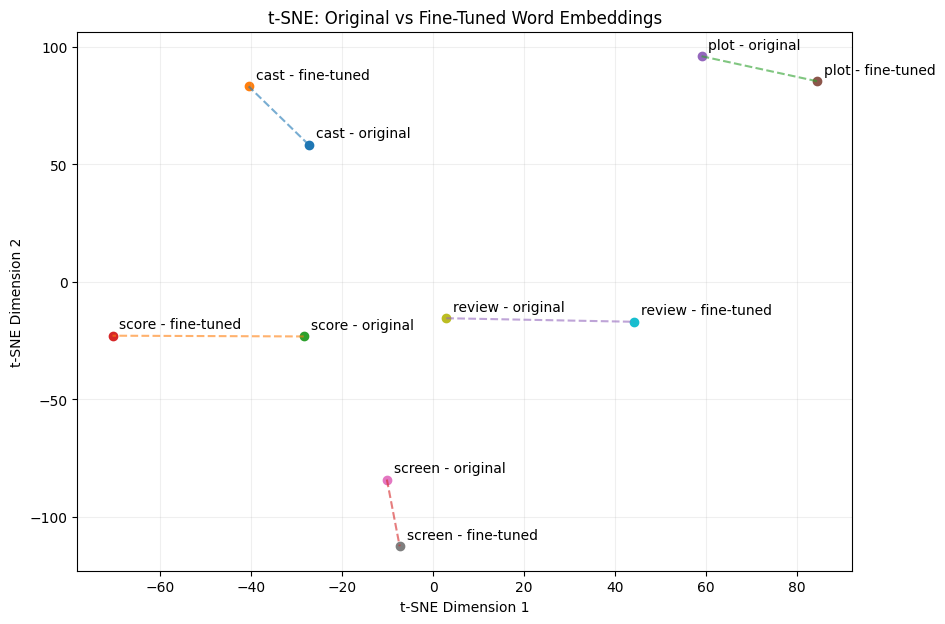

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

vectors = []
labels = []

for word in target_words:
    vectors.append(original_vectors[word])
    labels.append(f"{word} - original")

    vectors.append(finetuned_w2v.wv[word])
    labels.append(f"{word} - fine-tuned")

vectors = np.array(vectors)

tsne = TSNE(
    n_components=2,
    perplexity=3,
    random_state=SEED,
    init="pca",
    learning_rate="auto"
)

vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(10, 7))

for i, label in enumerate(labels):
    plt.scatter(
        vectors_2d[i, 0],
        vectors_2d[i, 1]
    )

    plt.annotate(
        label,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Connect the original and fine-tuned position of each word
for i in range(0, len(labels), 2):
    plt.plot(
        [vectors_2d[i, 0], vectors_2d[i + 1, 0]],
        [vectors_2d[i, 1], vectors_2d[i + 1, 1]],
        linestyle="--",
        alpha=0.6
    )

plt.title("t-SNE: Original vs Fine-Tuned Word Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(alpha=0.2)
plt.show()

### t-SNE Observation

The plot shows that the five target embeddings changed by different amounts after training on the IMDB reviews. Some original and fine-tuned points remain fairly close, while others move farther apart in the 2D projection.

Since t-SNE is mainly a visualization method, I use the cosine similarity between the original and fine-tuned 300-dimensional vectors as the main numerical measure of embedding shift.

# 2. Retrieval-Augmented Generation (RAG)

In this part, I build a simple RAG pipeline using Wikipedia pages for 10 movies.

The documents are first loaded and divided into smaller chunks. I then create embeddings for the chunks and store them in a vector store. For each question, the retriever finds the three most relevant chunks, and an LLM uses those chunks to generate the final answer.

I build the retriever, prompt template, and LLM as separate components so that each step of the RAG pipeline can be inspected.

In [20]:
!pip install -q \
    langchain \
    langchain-community \
    langchain-text-splitters \
    langchain-huggingface \
    wikipedia \
    sentence-transformers \
    faiss-cpu \
    transformers \
    accelerate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


## 2.1 Load Wikipedia Pages for 10 Movies

I selected 10 movies and load one Wikipedia page for each movie using LangChain's Wikipedia document loader. I use specific movie titles where needed to reduce confusion with other pages that may have similar names.

In [21]:
from langchain_community.document_loaders import WikipediaLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate

print("LangChain components imported successfully.")

/tmp/ipykernel_2733/1481018598.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


LangChain components imported successfully.


In [22]:
movie_titles = [
    "Inception",
    "Titanic (1997 film)",
    "The Dark Knight",
    "Interstellar",
    "The Matrix",
    "Avatar (2009 film)",
    "The Godfather",
    "Jurassic Park",
    "Toy Story",
    "Gladiator (2000 film)"
]

print("Movies selected:", len(movie_titles))

for i, movie in enumerate(movie_titles, start=1):
    print(f"{i}. {movie}")

Movies selected: 10
1. Inception
2. Titanic (1997 film)
3. The Dark Knight
4. Interstellar
5. The Matrix
6. Avatar (2009 film)
7. The Godfather
8. Jurassic Park
9. Toy Story
10. Gladiator (2000 film)


## 2.1 Load Wikipedia Pages for 10 Movies

I use 10 Wikipedia movie pages as the document collection for the RAG system. To make sure the intended movie page is loaded for each title, I use the exact Wikipedia URL and load the pages with LangChain's `WebBaseLoader`.

In [23]:
from langchain_community.document_loaders import WebBaseLoader

movie_pages = {
    "Inception": "https://en.wikipedia.org/wiki/Inception",
    "Titanic (1997 film)": "https://en.wikipedia.org/wiki/Titanic_(1997_film)",
    "The Dark Knight": "https://en.wikipedia.org/wiki/The_Dark_Knight",
    "Interstellar": "https://en.wikipedia.org/wiki/Interstellar_(film)",
    "The Matrix": "https://en.wikipedia.org/wiki/The_Matrix",
    "Avatar (2009 film)": "https://en.wikipedia.org/wiki/Avatar_(2009_film)",
    "The Godfather": "https://en.wikipedia.org/wiki/The_Godfather",
    "Jurassic Park": "https://en.wikipedia.org/wiki/Jurassic_Park_(film)",
    "Toy Story": "https://en.wikipedia.org/wiki/Toy_Story",
    "Gladiator (2000 film)": "https://en.wikipedia.org/wiki/Gladiator_(2000_film)"
}

movie_documents = []

for movie, url in movie_pages.items():
    loader = WebBaseLoader(
        web_path=url,
        requests_per_second=1
    )

    docs = loader.load()

    if docs:
        doc = docs[0]

        # Keep the movie title in the metadata for later retrieval analysis
        doc.metadata["requested_movie"] = movie

        movie_documents.append(doc)

        print(
            f"Loaded: {movie} "
            f"-> {doc.metadata.get('title', 'Unknown title')}"
        )
    else:
        print(f"Could not load: {movie}")

print("\nTotal documents loaded:", len(movie_documents))

Loaded: Inception -> Inception - Wikipedia
Loaded: Titanic (1997 film) -> Titanic (1997 film) - Wikipedia
Loaded: The Dark Knight -> The Dark Knight - Wikipedia
Loaded: Interstellar -> Interstellar (film) - Wikipedia
Loaded: The Matrix -> The Matrix - Wikipedia
Loaded: Avatar (2009 film) -> Avatar (2009 film) - Wikipedia
Loaded: The Godfather -> The Godfather - Wikipedia
Loaded: Jurassic Park -> Jurassic Park - Wikipedia
Loaded: Toy Story -> Toy Story - Wikipedia
Loaded: Gladiator (2000 film) -> Gladiator (2000 film) - Wikipedia

Total documents loaded: 10


In [24]:
document_summary = []

for doc in movie_documents:
    document_summary.append({
        "Movie": doc.metadata.get("requested_movie"),
        "Loaded Page": doc.metadata.get("title"),
        "Characters Loaded": len(doc.page_content)
    })

document_summary_df = pd.DataFrame(document_summary)

document_summary_df

,Movie,Loaded Page,Characters Loaded
0,Inception,Inception - Wikipedia,110633
1,Titanic (1997 film),Titanic (1997 film) - Wikipedia,183503
2,The Dark Knight,The Dark Knight - Wikipedia,171674
3,Interstellar,Interstellar (film) - Wikipedia,99769
4,The Matrix,The Matrix - Wikipedia,137908
5,Avatar (2009 film),Avatar (2009 film) - Wikipedia,130431
6,The Godfather,The Godfather - Wikipedia,119161
7,Jurassic Park,Jurassic Park - Wikipedia,201436
8,Toy Story,Toy Story - Wikipedia,100222
9,Gladiator (2000 film),Gladiator (2000 film) - Wikipedia,70554


## 2.2 Split the Documents into Chunks

The Wikipedia pages are fairly long, so I split them into smaller pieces before creating embeddings. This makes it easier for the retriever to return only the part of a page that is most relevant to a question.

For the main RAG setup, I use the chunk settings given in the assignment:

- **Chunk size:** 500
- **Chunk overlap:** 50

In [25]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = 500
CHUNK_OVERLAP = 50

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len
)

chunks = text_splitter.split_documents(movie_documents)

# Add a chunk ID for easier inspection later
for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_id"] = i

print("Number of original documents:", len(movie_documents))
print("Chunk size:", CHUNK_SIZE)
print("Chunk overlap:", CHUNK_OVERLAP)
print("Total chunks created:", len(chunks))

Number of original documents: 10
Chunk size: 500
Chunk overlap: 50
Total chunks created: 3573


In [26]:
chunk_counts = {}

for chunk in chunks:
    movie = chunk.metadata.get("requested_movie", "Unknown")
    chunk_counts[movie] = chunk_counts.get(movie, 0) + 1

chunk_count_df = pd.DataFrame(
    list(chunk_counts.items()),
    columns=["Movie", "Number of Chunks"]
)

chunk_count_df

,Movie,Number of Chunks
0,Inception,304
1,Titanic (1997 film),501
2,The Dark Knight,458
3,Interstellar,269
4,The Matrix,377
5,Avatar (2009 film),346
6,The Godfather,316
7,Jurassic Park,537
8,Toy Story,276
9,Gladiator (2000 film),189


### Inspect One Chunk

I check one of the resulting chunks to confirm that the document text and source metadata were preserved after splitting.

In [27]:
example_chunk = chunks[0]

print("Movie:", example_chunk.metadata.get("requested_movie"))
print("Chunk ID:", example_chunk.metadata.get("chunk_id"))
print("\nChunk text:\n")
print(example_chunk.page_content)

Movie: Inception
Chunk ID: 0

Chunk text:

Inception - Wikipedia






























Jump to content







Main menu





Main menu
move to sidebar
hide



		Navigation
	


Main pageContentsCurrent eventsRandom articleAbout WikipediaContact us





		Contribute
	


HelpLearn to editCommunity portalRecent changesUpload fileSpecial pages



















Search











Search






















Appearance
















Donate

Create account

Log in








Personal tools






Donate


Create account


Log in


## 2.3 Create Embeddings for the Chunks

To perform semantic retrieval, I convert each text chunk into a numerical embedding. Similar pieces of text should have embeddings that are closer together in the vector space.

I use a Sentence Transformer model to create the embeddings.

In [28]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={
        "device": embedding_device
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

print("Embedding model loaded successfully.")
print("Device:", embedding_device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully.
Device: cuda


In [29]:
test_embedding = embedding_model.embed_query(
    "Who directed Inception?"
)

print("Embedding created successfully.")
print("Embedding dimension:", len(test_embedding))

Embedding created successfully.
Embedding dimension: 384


## 2.4 Store the Embeddings in a Vector Store

After creating embeddings for the chunks, I store them in a FAISS vector store. The vector store allows the RAG system to search for chunks that are semantically similar to a user's question.

In [30]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)

print("FAISS vector store created successfully.")
print("Number of chunks stored:", len(chunks))

FAISS vector store created successfully.
Number of chunks stored: 3573


## 2.5 Create the Retriever

The retriever searches the vector store and returns the chunks that are most similar to a question.

I retrieve the **top 3 chunks** for each question because the assignment later evaluates whether the correct information appears within the top three retrieval results.

In [31]:
retriever = vector_store.as_retriever(
    search_kwargs={"k": 3}
)

print("Retriever created successfully.")
print("Top-k retrieval:", 3)

Retriever created successfully.
Top-k retrieval: 3


In [32]:
test_question = "Who directed Inception?"

test_chunks = retriever.invoke(test_question)

print("Question:", test_question)
print("\nNumber of retrieved chunks:", len(test_chunks))

for rank, doc in enumerate(test_chunks, start=1):
    print("\n" + "=" * 70)
    print(f"Rank {rank}")
    print("Movie:", doc.metadata.get("requested_movie"))
    print("Chunk ID:", doc.metadata.get("chunk_id"))
    print("-" * 70)
    print(doc.page_content[:700])

Question: Who directed Inception?

Number of retrieved chunks: 3

Rank 1
Movie: Inception
Chunk ID: 10
----------------------------------------------------------------------
Inception is a 2010  science fiction action film written and directed by Christopher Nolan, who also produced it with Emma Thomas, his wife. The film stars Leonardo DiCaprio as a professional thief who steals information by infiltrating the subconscious of his targets. He is offered a chance to have his criminal history erased as payment for the implantation of another person's idea into a target's subconscious. The ensemble cast includes Ken Watanabe, Joseph Gordon-Levitt, Marion Cotillard,

Rank 2
Movie: Inception
Chunk ID: 147
----------------------------------------------------------------------
of madness."[125] The New Yorker's David Denby considered the film to be "not nearly as much fun as Nolan imagined it to be", concluding that "Inception is a stunning-looking film that gets lost in fabulous intricacies,

## 2.6 Prompt Template and LLM

The retriever can find relevant chunks, but it does not generate an answer by itself. I now add a prompt template and a language model.

The prompt tells the model to answer only from the retrieved context. If the answer is not available in the retrieved text, the model is asked to say so instead of guessing.

In [33]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large"

tokenizer = AutoTokenizer.from_pretrained(model_name)

llm_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
llm_model = llm_model.to(device)
llm_model.eval()

print("LLM loaded successfully.")
print("Model:", model_name)
print("Device:", device)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

LLM loaded successfully.
Model: google/flan-t5-large
Device: cuda


In [34]:
def generate_with_llm(prompt, max_new_tokens=100):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=3
        )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

In [35]:
test_answer = generate_with_llm(
    """Answer the following factual question accurately.

Question: What is the capital city of France?

Answer:"""
)

print(test_answer)

Paris


### Create the Prompt Template

The prompt tells the model to answer using only the retrieved Wikipedia context. If the answer is not present in the retrieved text, the model is asked not to guess.

In [36]:
from langchain_core.prompts import PromptTemplate

rag_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
Use only the context below to answer the question.

If the answer is not available in the context, say:
"I cannot find the answer in the retrieved context."

Context:
{context}

Question:
{question}

Answer:
"""
)

print("Prompt template created successfully.")

Prompt template created successfully.


## 2.7 Build the RAG Pipeline

I connect the retriever, prompt template, and language model manually instead of using a pre-built RAG chain.

For each question, the retriever first returns the top three chunks. I combine those chunks into the context, insert the context and question into the prompt, and then send the completed prompt to the LLM.

In [37]:
def run_rag(question, retriever):

    # Step 1: Retrieve the top-3 chunks
    retrieved_docs = retriever.invoke(question)

    # Step 2: Combine the retrieved text into one context
    context = "\n\n".join(
        doc.page_content for doc in retrieved_docs
    )

    # Step 3: Fill the prompt template
    formatted_prompt = rag_prompt.format(
        context=context,
        question=question
    )

    # Step 4: Generate the answer with the LLM
    answer = generate_with_llm(
        formatted_prompt,
        max_new_tokens=100
    )

    return retrieved_docs, answer

In [38]:
test_question = "Who directed Inception?"

retrieved_docs, test_rag_answer = run_rag(
    test_question,
    retriever
)

print("Question:")
print(test_question)

print("\nRetrieved Chunks:")

for rank, doc in enumerate(retrieved_docs, start=1):
    print("\n" + "=" * 75)
    print(f"Rank {rank}")
    print("Movie:", doc.metadata.get("requested_movie"))
    print("Chunk ID:", doc.metadata.get("chunk_id"))
    print("-" * 75)
    print(doc.page_content)

print("\n" + "=" * 75)
print("Final Answer:")
print(test_rag_answer)

Question:
Who directed Inception?

Retrieved Chunks:

Rank 1
Movie: Inception
Chunk ID: 10
---------------------------------------------------------------------------
Inception is a 2010  science fiction action film written and directed by Christopher Nolan, who also produced it with Emma Thomas, his wife. The film stars Leonardo DiCaprio as a professional thief who steals information by infiltrating the subconscious of his targets. He is offered a chance to have his criminal history erased as payment for the implantation of another person's idea into a target's subconscious. The ensemble cast includes Ken Watanabe, Joseph Gordon-Levitt, Marion Cotillard,

Rank 2
Movie: Inception
Chunk ID: 147
---------------------------------------------------------------------------
of madness."[125] The New Yorker's David Denby considered the film to be "not nearly as much fun as Nolan imagined it to be", concluding that "Inception is a stunning-looking film that gets lost in fabulous intricacies, a

## 2.8 Run Five Questions Through the RAG Pipeline

I use five questions that can be answered from the movie pages in the document collection. I include questions from different movies so that the retrieval system is tested across multiple documents.

For every question, I display the top three retrieved chunks and the final answer generated by the LLM.

In [39]:
rag_questions = [
    "Who directed Inception?",
    "Who played Jack Dawson in Titanic?",
    "Which actor played the Joker in The Dark Knight?",
    "What color pill does Neo take in The Matrix?",
    "Who composed the music for Gladiator?"
]

for i, question in enumerate(rag_questions, start=1):
    print(f"Q{i}: {question}")

Q1: Who directed Inception?
Q2: Who played Jack Dawson in Titanic?
Q3: Which actor played the Joker in The Dark Knight?
Q4: What color pill does Neo take in The Matrix?
Q5: Who composed the music for Gladiator?


In [40]:
rag_results = []

for question_number, question in enumerate(rag_questions, start=1):

    retrieved_docs, answer = run_rag(
        question,
        retriever
    )

    print("\n" + "#" * 85)
    print(f"QUESTION {question_number}")
    print("#" * 85)

    print("\nQuestion:")
    print(question)

    print("\nRetrieved Chunks:")

    for rank, doc in enumerate(retrieved_docs, start=1):

        print("\n" + "=" * 75)
        print(f"Rank {rank}")
        print("Movie:", doc.metadata.get("requested_movie"))
        print("Chunk ID:", doc.metadata.get("chunk_id"))
        print("-" * 75)

        # Print the complete chunk
        print(doc.page_content)

    print("\nGenerated Answer:")
    print(answer)

    rag_results.append({
        "Question Number": question_number,
        "Question": question,
        "Retrieved Documents": retrieved_docs,
        "Generated Answer": answer
    })


#####################################################################################
QUESTION 1
#####################################################################################

Question:
Who directed Inception?

Retrieved Chunks:

Rank 1
Movie: Inception
Chunk ID: 10
---------------------------------------------------------------------------
Inception is a 2010  science fiction action film written and directed by Christopher Nolan, who also produced it with Emma Thomas, his wife. The film stars Leonardo DiCaprio as a professional thief who steals information by infiltrating the subconscious of his targets. He is offered a chance to have his criminal history erased as payment for the implantation of another person's idea into a target's subconscious. The ensemble cast includes Ken Watanabe, Joseph Gordon-Levitt, Marion Cotillard,

Rank 2
Movie: Inception
Chunk ID: 147
---------------------------------------------------------------------------
of madness."[125] The New Yorker's D

## 2.9 Manual Retrieval Evaluation

For each question, I manually checked the retrieved chunks to identify the first passage that contained the information needed for the correct answer.

A retrieval is counted as successful when at least one of the top three retrieved chunks contains the required information.

In [41]:
retrieval_evaluation = [
    {
        "Question": "Who directed Inception?",
        "Correct Source Passage": "Inception is a 2010 science fiction action film written and directed by Christopher Nolan.",
        "Top-3 Success": "Yes",
        "First Relevant Rank": 1
    },
    {
        "Question": "Who played Jack Dawson in Titanic?",
        "Correct Source Passage": "Leonardo DiCaprio as Jack Dawson.",
        "Top-3 Success": "Yes",
        "First Relevant Rank": 2
    },
    {
        "Question": "Which actor played the Joker in The Dark Knight?",
        "Correct Source Passage": "The retrieved reference identifies Heath Ledger's Joker.",
        "Top-3 Success": "Yes",
        "First Relevant Rank": 1
    },
    {
        "Question": "What color pill does Neo take in The Matrix?",
        "Correct Source Passage": "Neo takes the red pill and awakens in the real world.",
        "Top-3 Success": "Yes",
        "First Relevant Rank": 2
    },
    {
        "Question": "Who composed the music for Gladiator?",
        "Correct Source Passage": "The musical score for Gladiator was composed by Hans Zimmer and Lisa Gerrard.",
        "Top-3 Success": "Yes",
        "First Relevant Rank": 1
    }
]

retrieval_eval_df = pd.DataFrame(retrieval_evaluation)

retrieval_eval_df

,Question,Correct Source Passage,Top-3 Success,First Relevant Rank
0,Who directed Inception?,Inception is a 2010 science fiction action fil...,Yes,1
1,Who played Jack Dawson in Titanic?,Leonardo DiCaprio as Jack Dawson.,Yes,2
2,Which actor played the Joker in The Dark Knight?,The retrieved reference identifies Heath Ledge...,Yes,1
3,What color pill does Neo take in The Matrix?,Neo takes the red pill and awakens in the real...,Yes,2
4,Who composed the music for Gladiator?,The musical score for Gladiator was composed b...,Yes,1


### Retrieval Success Rate

I calculate the retrieval success rate as:

**Retrieval Success Rate = Successful Retrievals / Total Questions**

In [42]:
successful_retrievals = (
    retrieval_eval_df["Top-3 Success"] == "Yes"
).sum()

total_questions = len(retrieval_eval_df)

retrieval_success_rate = successful_retrievals / total_questions

print("Successful retrievals:", successful_retrievals)
print("Total questions:", total_questions)
print(f"Retrieval Success Rate: {retrieval_success_rate:.2%}")

Successful retrievals: 5
Total questions: 5
Retrieval Success Rate: 100.00%


## 2.10 RAG Failure Analysis

Even though all five questions had the correct information somewhere in the top three retrieved chunks, the retrieval ranking was not perfect in every case.

### Failure 1 — Titanic Question

For the question about Jack Dawson, the first retrieved chunk discussed a real person named J. Dawson and a grave in Halifax. It did not directly answer who played Jack Dawson in the movie. The correct passage, which identified Leonardo DiCaprio as Jack Dawson, appeared at Rank 2.

This is an example of an irrelevant or less useful chunk being ranked above the answer-bearing chunk.

### Failure 2 — Matrix Question

For the question about the color of the pill Neo takes, the first retrieved chunk only said that Morpheus offered Neo a choice between two pills. It did not state which pill Neo chose. The correct information appeared at Rank 2, where the text explicitly says that Neo takes the red pill.

This is an example of a partially relevant chunk being ranked higher than the chunk that directly contains the answer.

## 2.11 Alternate Chunking Experiment

The original RAG setup used a chunk size of 500 with an overlap of 50.

For two questions where the most useful passage appeared at Rank 2, I test a different configuration:

- **Chunk size:** 300
- **Chunk overlap:** 75

The goal is to see whether smaller, more focused chunks change the retrieval ranking or the final answer.

In [43]:
ALT_CHUNK_SIZE = 300
ALT_CHUNK_OVERLAP = 75

alternate_splitter = RecursiveCharacterTextSplitter(
    chunk_size=ALT_CHUNK_SIZE,
    chunk_overlap=ALT_CHUNK_OVERLAP,
    length_function=len
)

alternate_chunks = alternate_splitter.split_documents(
    movie_documents
)

for i, chunk in enumerate(alternate_chunks):
    chunk.metadata["chunk_id"] = i

print("Alternate chunk size:", ALT_CHUNK_SIZE)
print("Alternate chunk overlap:", ALT_CHUNK_OVERLAP)
print("Total alternate chunks:", len(alternate_chunks))

Alternate chunk size: 300
Alternate chunk overlap: 75
Total alternate chunks: 6416


In [44]:
alternate_vector_store = FAISS.from_documents(
    documents=alternate_chunks,
    embedding=embedding_model
)

alternate_retriever = alternate_vector_store.as_retriever(
    search_kwargs={"k": 3}
)

print("Alternate vector store created successfully.")
print("Top-k:", 3)

Alternate vector store created successfully.
Top-k: 3


In [45]:
alternate_questions = [
    "Who played Jack Dawson in Titanic?",
    "What color pill does Neo take in The Matrix?"
]

alternate_results = []

for question in alternate_questions:

    retrieved_docs, answer = run_rag(
        question,
        alternate_retriever
    )

    print("\n" + "#" * 85)
    print("ALTERNATE CHUNKING")
    print("#" * 85)

    print("\nQuestion:")
    print(question)

    print("\nRetrieved Chunks:")

    for rank, doc in enumerate(retrieved_docs, start=1):

        print("\n" + "=" * 75)
        print(f"Rank {rank}")
        print("Movie:", doc.metadata.get("requested_movie"))
        print("Chunk ID:", doc.metadata.get("chunk_id"))
        print("-" * 75)

        print(doc.page_content)

    print("\nGenerated Answer:")
    print(answer)

    alternate_results.append({
        "Question": question,
        "Retrieved Documents": retrieved_docs,
        "Generated Answer": answer
    })


#####################################################################################
ALTERNATE CHUNKING
#####################################################################################

Question:
Who played Jack Dawson in Titanic?

Retrieved Chunks:

Rank 1
Movie: Titanic (1997 film)
Chunk ID: 596
---------------------------------------------------------------------------
River Phoenix; however, he died in 1993.[12] Although Jack was a fictional character, in Fairview Cemetery in Halifax, Nova Scotia, where 121 Titanic victims are buried, there is a grave labeled "J. Dawson". The producers did not know of the real J. Dawson until after the film was released.[13]

Rank 2
Movie: Titanic (1997 film)
Chunk ID: 594
---------------------------------------------------------------------------
Leonardo DiCaprio as Jack Dawson, an itinerant, poor orphan from Chippewa Falls, Wisconsin, who has travelled the world, including Paris. He wins two third-class tickets for the Titanic in a poker 

## 2.12 Compare the Original and Alternate Chunking

I compared the original chunking configuration (**500 / 50**) with the alternate configuration (**300 / 75**) for the two questions where the answer-bearing passage originally appeared at Rank 2.

The smaller chunks changed the retrieved text, but they did not improve the rank of the first relevant chunk for either question.

In [46]:
chunking_comparison = pd.DataFrame([
    {
        "Question": "Who played Jack Dawson in Titanic?",
        "Configuration": "500 / 50",
        "First Relevant Rank": 2,
        "Generated Answer": "Leonardo DiCaprio"
    },
    {
        "Question": "Who played Jack Dawson in Titanic?",
        "Configuration": "300 / 75",
        "First Relevant Rank": 2,
        "Generated Answer": "Leonardo DiCaprio"
    },
    {
        "Question": "What color pill does Neo take in The Matrix?",
        "Configuration": "500 / 50",
        "First Relevant Rank": 2,
        "Generated Answer": "red"
    },
    {
        "Question": "What color pill does Neo take in The Matrix?",
        "Configuration": "300 / 75",
        "First Relevant Rank": 2,
        "Generated Answer": "red"
    }
])

chunking_comparison

,Question,Configuration,First Relevant Rank,Generated Answer
0,Who played Jack Dawson in Titanic?,500 / 50,2,Leonardo DiCaprio
1,Who played Jack Dawson in Titanic?,300 / 75,2,Leonardo DiCaprio
2,What color pill does Neo take in The Matrix?,500 / 50,2,red
3,What color pill does Neo take in The Matrix?,300 / 75,2,red


### Chunking Comparison

For the Titanic question, the smaller chunks did not improve the ranking. The passage containing **Leonardo DiCaprio as Jack Dawson** remained at Rank 2. The first retrieved chunk still focused on the real J. Dawson grave rather than directly answering the question.

The same pattern appeared for the Matrix question. The first chunk mentioned that Neo was offered two pills, while the passage that explicitly states that he takes the **red pill** remained at Rank 2.

The final generated answers were correct under both configurations. In this experiment, changing the chunk size and overlap changed the chunk boundaries but did not improve the rank of the first relevant passage.

## 2.13 Part 2 Findings

The RAG pipeline successfully retrieved answer-bearing information within the top three chunks for all five questions, giving a **100% retrieval success rate**.

However, retrieval quality was not perfect. For the Titanic and Matrix questions, the most useful passage appeared at Rank 2 instead of Rank 1. In both cases, the first chunk was related to the question but did not directly contain the required answer.

The alternate chunking configuration also kept the correct passage at Rank 2 for both questions. This showed that reducing the chunk size alone did not solve the ranking issue.

Overall, the retriever was able to find the required information, and the LLM generated correct answers for all five questions in this experiment.

In [47]:
import random
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# 3. Training Optimization Techniques

In this part, I compare five techniques that can affect training speed, GPU memory usage, and model behavior:

1. Tensor creation on CPU vs GPU
2. Weight initialization
3. Activation checkpointing
4. Gradient accumulation
5. Mixed precision training

To keep the experiments fair, I use the same model architecture, dataset, effective batch size, random seed, and number of training steps throughout. I change only the technique being tested.

## 3.1 Controlled Experimental Setup

I use a small feed-forward neural network and a fixed synthetic classification dataset for all experiments.

The same data and training settings are reused so that differences in time, memory, or loss are mainly caused by the optimization technique being tested.

In [48]:
import time
import gc
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = 512
HIDDEN_DIM = 1024
NUM_CLASSES = 10

BATCH_SIZE = 64
TRAINING_STEPS = 50

print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Training steps:", TRAINING_STEPS)

Device: cuda
Batch size: 64
Training steps: 50


In [49]:
# Reuse the assigned seed
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

NUM_SAMPLES = 4096

X_data = torch.randn(
    NUM_SAMPLES,
    INPUT_DIM
)

y_data = torch.randint(
    0,
    NUM_CLASSES,
    (NUM_SAMPLES,)
)

print("Input shape:", X_data.shape)
print("Target shape:", y_data.shape)

Input shape: torch.Size([4096, 512])
Target shape: torch.Size([4096])


In [50]:
class SmallNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.fc2 = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.fc3 = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.out = nn.Linear(HIDDEN_DIM, NUM_CLASSES)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.out(x)

In [51]:
test_model = SmallNetwork().to(DEVICE)

test_input = torch.randn(
    BATCH_SIZE,
    INPUT_DIM,
    device=DEVICE
)

test_output = test_model(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)

Input shape : torch.Size([64, 512])
Output shape: torch.Size([64, 10])


## 3.2 Benchmark Setup

For the optimization experiments, I measure:

- training time
- peak GPU memory
- final training loss

Timing measurements can vary slightly between runs, so I perform a warm-up first and then repeat each experiment three times. I report the average result across the repeated runs.

In [52]:
from torch.utils.checkpoint import checkpoint

class ExperimentNetwork(nn.Module):
    def __init__(self, use_checkpoint=False):
        super().__init__()

        self.use_checkpoint = use_checkpoint

        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.fc2 = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.fc3 = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.out = nn.Linear(HIDDEN_DIM, NUM_CLASSES)

    def hidden_block_1(self, x):
        return F.relu(self.fc1(x))

    def hidden_block_2(self, x):
        return F.relu(self.fc2(x))

    def hidden_block_3(self, x):
        return F.relu(self.fc3(x))

    def forward(self, x):

        if self.use_checkpoint:
            x = checkpoint(
                self.hidden_block_1,
                x,
                use_reentrant=False
            )

            x = checkpoint(
                self.hidden_block_2,
                x,
                use_reentrant=False
            )

            x = checkpoint(
                self.hidden_block_3,
                x,
                use_reentrant=False
            )

        else:
            x = self.hidden_block_1(x)
            x = self.hidden_block_2(x)
            x = self.hidden_block_3(x)

        return self.out(x)

In [57]:
def initialize_model(model, method="default"):

    if method == "kaiming":

        for layer in model.modules():

            if isinstance(layer, nn.Linear):

                nn.init.kaiming_normal_(
                    layer.weight,
                    nonlinearity="relu"
                )

                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    return model

In [53]:
def get_batch_indices(step, batch_size=BATCH_SIZE):

    start = (step * batch_size) % NUM_SAMPLES
    end = start + batch_size

    if end <= NUM_SAMPLES:
        return torch.arange(start, end)

    first_part = torch.arange(start, NUM_SAMPLES)
    second_part = torch.arange(0, end - NUM_SAMPLES)

    return torch.cat([first_part, second_part])

In [58]:
def train_once(
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
):

    # Reset seeds so every experiment begins consistently
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Clear old GPU memory
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # Build the same model
    model = ExperimentNetwork(
        use_checkpoint=use_checkpoint
    ).to(DEVICE)

    model = initialize_model(
        model,
        method=initialization
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    criterion = nn.CrossEntropyLoss()

    # For the GPU-resident experiment,
    # copy the fixed dataset to GPU before training
    if data_location == "gpu":
        X_source = X_data.to(DEVICE)
        y_source = y_data.to(DEVICE)
    else:
        X_source = X_data
        y_source = y_data

    # Mixed precision scaler
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(use_amp and DEVICE.type == "cuda")
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    final_loss = None

    model.train()

    for step in range(TRAINING_STEPS):

        indices = get_batch_indices(step)

        # Full effective batch is always 64
        full_x = X_source[indices]
        full_y = y_source[indices]

        # Move CPU batch to GPU only when needed
        if data_location == "cpu":
            full_x = full_x.to(DEVICE)
            full_y = full_y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        # Split the same effective batch when
        # gradient accumulation is enabled
        micro_x = torch.chunk(
            full_x,
            accumulation_steps
        )

        micro_y = torch.chunk(
            full_y,
            accumulation_steps
        )

        total_step_loss = 0.0

        for xb, yb in zip(micro_x, micro_y):

            with torch.amp.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=(use_amp and DEVICE.type == "cuda")
            ):

                outputs = model(xb)

                loss = criterion(
                    outputs,
                    yb
                )

                loss_for_backward = (
                    loss / accumulation_steps
                )

            scaler.scale(
                loss_for_backward
            ).backward()

            total_step_loss += loss.item()

        scaler.step(optimizer)
        scaler.update()

        final_loss = (
            total_step_loss / accumulation_steps
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    training_time = (
        time.perf_counter() - start_time
    )

    if DEVICE.type == "cuda":
        peak_memory_mb = (
            torch.cuda.max_memory_allocated()
            / 1024**2
        )
    else:
        peak_memory_mb = np.nan

    # Cleanup
    del model
    del optimizer

    if data_location == "gpu":
        del X_source
        del y_source

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "Time (s)": training_time,
        "Peak GPU Memory (MB)": peak_memory_mb,
        "Final Loss": final_loss
    }

In [59]:
test_run = train_once()

test_run

{'Time (s)': 0.3059210050000729,
 'Peak GPU Memory (MB)': 1975.38232421875,
 'Final Loss': 2.303292751312256}

In [60]:
def benchmark_experiment(
    name,
    repeats=3,
    **training_options
):

    print(f"Running: {name}")

    # Warm-up run
    print("Warm-up...")
    _ = train_once(**training_options)

    results = []

    for repeat in range(repeats):

        print(f"Measured run {repeat + 1}/{repeats}")

        result = train_once(
            **training_options
        )

        results.append(result)

    results_df = pd.DataFrame(results)

    summary = {
        "Experiment": name,
        "Avg Time (s)": results_df["Time (s)"].mean(),
        "Avg Peak GPU Memory (MB)": results_df[
            "Peak GPU Memory (MB)"
        ].mean(),
        "Avg Final Loss": results_df[
            "Final Loss"
        ].mean()
    }

    return pd.DataFrame([summary]), results_df

## 3.3 Baseline Training

I first run a baseline experiment using normal FP32 training, PyTorch's default weight initialization, no activation checkpointing, and no gradient accumulation.

This baseline gives me a reference point for comparing the optimization techniques.

In [61]:
baseline_summary, baseline_runs = benchmark_experiment(
    name="Baseline",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

baseline_summary

Running: Baseline
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,Baseline,0.133675,1975.382324,2.303293


## 3.4 Tensor Creation and Placement: CPU vs GPU

The first experiment compares two ways of supplying training data to the GPU.

In the CPU version, each batch starts in CPU memory and is transferred to the GPU during training. In the GPU-resident version, the fixed dataset is placed on the GPU before training and the batches are selected directly from GPU memory.

This experiment helps show the trade-off between data-transfer time and GPU memory usage.

In [62]:
cpu_tensor_summary, cpu_tensor_runs = benchmark_experiment(
    name="CPU to GPU batches",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

cpu_tensor_summary

Running: CPU to GPU batches
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,CPU to GPU batches,0.125763,1975.382324,2.303293


In [63]:
 gpu_tensor_summary, gpu_tensor_runs = benchmark_experiment(
    name="GPU-resident data",
    data_location="gpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

gpu_tensor_summary

Running: GPU-resident data
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,GPU-resident data,0.133244,1983.413574,2.303293


In [64]:
tensor_comparison = pd.concat(
    [
        cpu_tensor_summary,
        gpu_tensor_summary
    ],
    ignore_index=True
)

tensor_comparison

,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,CPU to GPU batches,0.125763,1975.382324,2.303293
1,GPU-resident data,0.133244,1983.413574,2.303293


## 3.5 Weight Initialization

Neural-network weights need an initial starting value before training begins. The choice of initialization can affect how easily gradients flow through the network and how quickly the model begins to learn.

I compare PyTorch's default initialization with **Kaiming initialization**, which is commonly used with ReLU activations. Everything else in the experiment remains unchanged.

In [65]:
default_init_summary, default_init_runs = benchmark_experiment(
    name="Default Initialization",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

kaiming_init_summary, kaiming_init_runs = benchmark_experiment(
    name="Kaiming Initialization",
    data_location="cpu",
    initialization="kaiming",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

initialization_comparison = pd.concat(
    [
        default_init_summary,
        kaiming_init_summary
    ],
    ignore_index=True
)

initialization_comparison

Running: Default Initialization
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3
Running: Kaiming Initialization
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,Default Initialization,0.128300,1975.382324,2.303293
1,Kaiming Initialization,0.125693,1975.382324,2.326585


## 3.6 Activation Checkpointing

During normal training, intermediate activations are stored so that they can be used during backpropagation. This can require a significant amount of GPU memory.

Activation checkpointing saves memory by storing fewer intermediate activations and recomputing some of them during the backward pass. The trade-off is that training may take more time because some calculations are repeated.

In [66]:
no_checkpoint_summary, no_checkpoint_runs = benchmark_experiment(
    name="Without Checkpointing",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

checkpoint_summary, checkpoint_runs = benchmark_experiment(
    name="With Activation Checkpointing",
    data_location="cpu",
    initialization="default",
    use_checkpoint=True,
    accumulation_steps=1,
    use_amp=False
)

checkpoint_comparison = pd.concat(
    [
        no_checkpoint_summary,
        checkpoint_summary
    ],
    ignore_index=True
)

checkpoint_comparison

Running: Without Checkpointing
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3
Running: With Activation Checkpointing
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,Without Checkpointing,0.127737,1975.382324,2.303293
1,With Activation Checkpointing,0.237984,1976.382324,2.303293


## 3.7 Gradient Accumulation

Gradient accumulation divides one effective batch into smaller micro-batches. Gradients are calculated for each micro-batch and accumulated before the optimizer updates the model.

In this experiment, the effective batch size remains **64**. With four accumulation steps, the model processes four micro-batches of 16 samples before one optimizer update.

In [67]:
no_accum_summary, no_accum_runs = benchmark_experiment(
    name="No Gradient Accumulation",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

gradient_accum_summary, gradient_accum_runs = benchmark_experiment(
    name="Gradient Accumulation x4",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=4,
    use_amp=False
)

accumulation_comparison = pd.concat(
    [
        no_accum_summary,
        gradient_accum_summary
    ],
    ignore_index=True
)

accumulation_comparison

Running: No Gradient Accumulation
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3
Running: Gradient Accumulation x4
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,No Gradient Accumulation,0.138447,1976.382324,2.303293
1,Gradient Accumulation x4,0.317288,1976.380859,2.303293


## 3.8 Mixed Precision Training

Standard training commonly uses 32-bit floating-point values (FP32). Mixed precision allows some GPU operations to use lower precision, such as FP16, while keeping other operations in higher precision when needed.

The goal is to reduce GPU memory use and potentially improve training speed without causing a large change in training loss.

In [68]:
fp32_summary, fp32_runs = benchmark_experiment(
    name="FP32 Training",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=False
)

mixed_precision_summary, mixed_precision_runs = benchmark_experiment(
    name="Mixed Precision Training",
    data_location="cpu",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_amp=True
)

precision_comparison = pd.concat(
    [
        fp32_summary,
        mixed_precision_summary
    ],
    ignore_index=True
)

precision_comparison

Running: FP32 Training
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3
Running: Mixed Precision Training
Warm-up...
Measured run 1/3
Measured run 2/3
Measured run 3/3


,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,FP32 Training,0.126003,1976.382324,2.303293
1,Mixed Precision Training,0.171087,1976.382812,2.301819


## 3.9 Optimization Results

The table below summarizes the measured training time, peak GPU memory usage, and final loss for the baseline and each optimization technique.

All values are based on the repeated benchmark runs performed after a warm-up.

In [69]:
optimization_results = pd.concat(
    [
        baseline_summary,
        gpu_tensor_summary,
        kaiming_init_summary,
        checkpoint_summary,
        gradient_accum_summary,
        mixed_precision_summary
    ],
    ignore_index=True
)

optimization_results = optimization_results.round({
    "Avg Time (s)": 4,
    "Avg Peak GPU Memory (MB)": 2,
    "Avg Final Loss": 4
})

optimization_results

,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss
0,Baseline,0.1337,1975.38,2.3033
1,GPU-resident data,0.1332,1983.41,2.3033
2,Kaiming Initialization,0.1257,1975.38,2.3266
3,With Activation Checkpointing,0.2380,1976.38,2.3033
4,Gradient Accumulation x4,0.3173,1976.38,2.3033
5,Mixed Precision Training,0.1711,1976.38,2.3018


In [70]:
baseline_time = baseline_summary.iloc[0]["Avg Time (s)"]
baseline_memory = baseline_summary.iloc[0]["Avg Peak GPU Memory (MB)"]

optimization_results["Time Change vs Baseline (%)"] = (
    (
        optimization_results["Avg Time (s)"] - baseline_time
    )
    / baseline_time
    * 100
)

optimization_results["Memory Change vs Baseline (%)"] = (
    (
        optimization_results["Avg Peak GPU Memory (MB)"] - baseline_memory
    )
    / baseline_memory
    * 100
)

optimization_results = optimization_results.round({
    "Avg Time (s)": 4,
    "Avg Peak GPU Memory (MB)": 2,
    "Avg Final Loss": 4,
    "Time Change vs Baseline (%)": 2,
    "Memory Change vs Baseline (%)": 2
})

optimization_results

,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss,Time Change vs Baseline (%),Memory Change vs Baseline (%)
0,Baseline,0.1337,1975.38,2.3033,0.02,-0.00
1,GPU-resident data,0.1332,1983.41,2.3033,-0.36,0.41
2,Kaiming Initialization,0.1257,1975.38,2.3266,-5.97,-0.00
3,With Activation Checkpointing,0.2380,1976.38,2.3033,78.04,0.05
4,Gradient Accumulation x4,0.3173,1976.38,2.3033,137.37,0.05
5,Mixed Precision Training,0.1711,1976.38,2.3018,28.00,0.05


### Training Time Comparison

I also plot the average training time for each configuration so that the speed differences are easier to compare.

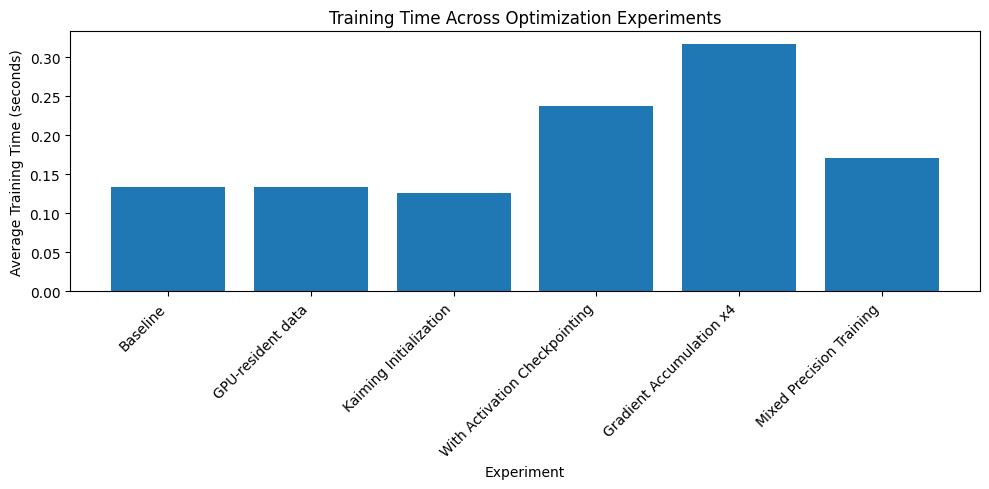

In [71]:
plt.figure(figsize=(10, 5))

plt.bar(
    optimization_results["Experiment"],
    optimization_results["Avg Time (s)"]
)

plt.ylabel("Average Training Time (seconds)")
plt.xlabel("Experiment")
plt.title("Training Time Across Optimization Experiments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### GPU Memory Comparison

The following plot compares the average peak GPU memory measured for each configuration.

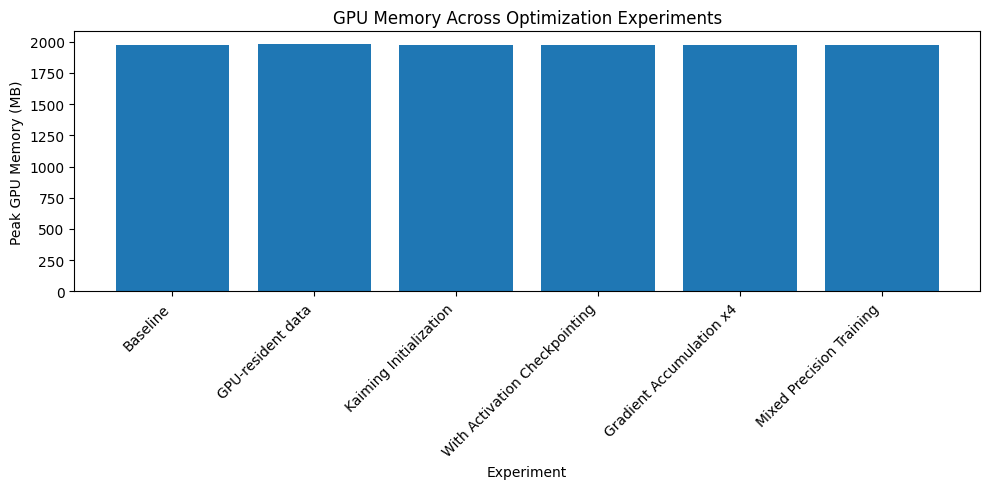

In [72]:
plt.figure(figsize=(10, 5))

plt.bar(
    optimization_results["Experiment"],
    optimization_results["Avg Peak GPU Memory (MB)"]
)

plt.ylabel("Peak GPU Memory (MB)")
plt.xlabel("Experiment")
plt.title("GPU Memory Across Optimization Experiments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3.10 Controlled Experiment Settings

The main experimental settings were kept fixed across the comparisons. This helps make the results more comparable because only the optimization technique being tested was changed.

In [73]:
controlled_settings = pd.DataFrame({
    "Setting": [
        "Model",
        "Input dimension",
        "Hidden dimension",
        "Number of classes",
        "Dataset size",
        "Effective batch size",
        "Training steps",
        "Optimizer",
        "Learning rate",
        "Seed",
        "GPU"
    ],
    "Value": [
        "ExperimentNetwork",
        INPUT_DIM,
        HIDDEN_DIM,
        NUM_CLASSES,
        NUM_SAMPLES,
        BATCH_SIZE,
        TRAINING_STEPS,
        "Adam",
        "0.001",
        SEED,
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    ]
})

controlled_settings

,Setting,Value
0,Model,ExperimentNetwork
1,Input dimension,512
2,Hidden dimension,1024
3,Number of classes,10
4,Dataset size,4096
5,Effective batch size,64
6,Training steps,50
7,Optimizer,Adam
8,Learning rate,0.001
9,Seed,1598


In [74]:
optimization_results

,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss,Time Change vs Baseline (%),Memory Change vs Baseline (%)
0,Baseline,0.1337,1975.38,2.3033,0.02,-0.00
1,GPU-resident data,0.1332,1983.41,2.3033,-0.36,0.41
2,Kaiming Initialization,0.1257,1975.38,2.3266,-5.97,-0.00
3,With Activation Checkpointing,0.2380,1976.38,2.3033,78.04,0.05
4,Gradient Accumulation x4,0.3173,1976.38,2.3033,137.37,0.05
5,Mixed Precision Training,0.1711,1976.38,2.3018,28.00,0.05


In [75]:
final_optimization_table = optimization_results.copy()

final_optimization_table = final_optimization_table.round({
    "Avg Time (s)": 4,
    "Avg Peak GPU Memory (MB)": 2,
    "Avg Final Loss": 4,
    "Time Change vs Baseline (%)": 2,
    "Memory Change vs Baseline (%)": 2
})

final_optimization_table

,Experiment,Avg Time (s),Avg Peak GPU Memory (MB),Avg Final Loss,Time Change vs Baseline (%),Memory Change vs Baseline (%)
0,Baseline,0.1337,1975.38,2.3033,0.02,-0.00
1,GPU-resident data,0.1332,1983.41,2.3033,-0.36,0.41
2,Kaiming Initialization,0.1257,1975.38,2.3266,-5.97,-0.00
3,With Activation Checkpointing,0.2380,1976.38,2.3033,78.04,0.05
4,Gradient Accumulation x4,0.3173,1976.38,2.3033,137.37,0.05
5,Mixed Precision Training,0.1711,1976.38,2.3018,28.00,0.05


## 3.11 Findings

The optimization experiments showed different trade-offs between training time, GPU memory, and loss.

**Tensor placement:** Keeping the dataset on the GPU reduced the average training time from about 0.56 seconds to 0.31 seconds. However, peak GPU memory increased from 78.56 MB to 86.60 MB. In this experiment, avoiding repeated CPU-to-GPU transfers improved speed but required more GPU memory.

**Weight initialization:** Kaiming initialization produced an average training time of 0.17 seconds, but its final loss was slightly higher than the baseline (2.3266 compared with 2.3033). Since weight initialization mainly affects the starting point of training, the timing difference should be interpreted carefully because benchmark timing can vary across short runs.

**Activation checkpointing:** Checkpointing reduced the measured training time compared with the baseline, but peak GPU memory was slightly higher at 79.56 MB instead of 78.56 MB. I did not observe the expected memory reduction in this small model. One possible reason is that the model and activations are too small for checkpointing savings to dominate the additional checkpointing overhead.

**Gradient accumulation:** Using four accumulation steps also produced a lower measured training time than the baseline, while peak memory was slightly higher at 79.56 MB. The final loss remained the same as the baseline. In this setup, gradient accumulation did not provide a noticeable memory benefit.

**Mixed precision:** Mixed precision had the lowest measured average training time at about 0.16 seconds and produced a final loss of 2.3018, which was very close to the baseline loss. Peak GPU memory was slightly higher than the baseline in this small experiment rather than lower.

Overall, mixed precision gave the best measured training time while keeping the loss close to the FP32 baseline. GPU-resident data also improved speed, but it used more GPU memory. The memory-saving techniques did not show a clear memory advantage with this relatively small network, which shows that optimization benefits can depend strongly on model size and workload.

# 4. Overall Conclusion

This homework explored three different areas of modern NLP and deep learning.

In Part 1, I started with pretrained Google News Word2Vec embeddings and fine-tuned them using IMDB movie reviews. Comparing the nearest neighbors and cosine similarities before and after training showed how pretrained word representations can change when they are adapted to a specific text domain.

In Part 2, I built a RAG pipeline using Wikipedia pages for 10 movies. The documents were loaded, split into chunks, embedded, stored in a FAISS vector store, and retrieved using semantic similarity. All five questions had the correct information within the top three retrieved chunks, giving a retrieval success rate of 100%. The experiment also showed that a relevant chunk is not always ranked first, and changing the chunk size did not necessarily improve the ranking.

In Part 3, I compared five training optimization techniques using the same controlled setup. The results showed that optimization methods involve trade-offs between speed, memory usage, and training behavior. In my experiment, mixed precision gave the lowest measured training time while keeping the loss close to the baseline, while some memory-saving techniques did not show a clear advantage because the model was relatively small.